In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

mobility = pd.read_csv("data/mobility_clean.csv")
mobility['date'] = pd.to_datetime(mobility['date'])
mobility["year_month"] = mobility["date"].dt.to_period('M')

monthly = mobility.groupby(['sub_region_2', 'year_month']).mean().reset_index()

# mobility columns
mobility_feats = [
    'retail_and_recreation_percent_change_from_baseline', 
    'grocery_and_pharmacy_percent_change_from_baseline', 
    'transit_stations_percent_change_from_baseline', 
    'workplaces_percent_change_from_baseline', 
    'residential_percent_change_from_baseline'
]


rural_counties = ["Accomack County","Alleghany County","Bath County",
                  "Bland County","Brunswick County","Buchanan County",
                  "Carroll County","Charlotte County","Craig County",
                  "Dickenson County","Essex County","Grayson County",
                  "Greensville County","Halifax County","Henry County",
                  "Highland County","Lee County","Louisa County",
                  "Lunenburg County","Madison County","Mecklenburg County",
                  "Middlesex County","Montgomery County","Nelson County",
                  "Northampton County","Northumberland County","Patrick County",
                  "Pittsylvania County","Prince Edward County","Pulaski County",
                  "Richmond County","Rockbridge County","Rockingham County",
                  "Russell County","Smyth County","Southampton County",
                  "Tazewell County","Wise County","Wythe County","Shenandoah County"]

mobility['metro_label'] = np.where(mobility['sub_region_2'].isin(rural_counties), 0, 1)
monthly['metro_label'] = np.where(monthly['sub_region_2'].isin(rural_counties), 0, 1)

# checkna
mobility_pca = mobility[mobility_feats]
monthly_pca = monthly[mobility_feats]

print(mobility_pca.isna().sum())
print(monthly_pca.isna().sum())


retail_and_recreation_percent_change_from_baseline    0
grocery_and_pharmacy_percent_change_from_baseline     0
transit_stations_percent_change_from_baseline         0
workplaces_percent_change_from_baseline               0
residential_percent_change_from_baseline              0
dtype: int64
retail_and_recreation_percent_change_from_baseline    0
grocery_and_pharmacy_percent_change_from_baseline     0
transit_stations_percent_change_from_baseline         0
workplaces_percent_change_from_baseline               0
residential_percent_change_from_baseline              0
dtype: int64


In [2]:
# scale data
scaler = StandardScaler()
mob_scaled = scaler.fit_transform(mobility_pca)

# pca
pca = PCA(n_components=2)
pca_result = pca.fit_transform(mob_scaled)

mobility['PC1'] = pca_result[:,0]
mobility['PC2'] = pca_result[:,1]

print(pca.explained_variance_ratio_)  # How much variance is captured


[0.56256845 0.1638252 ]


In [3]:
# scale data
scaler = StandardScaler()
monthly_scaled = scaler.fit_transform(monthly_pca)

pca_m = PCA(n_components=2)
monthly_result = pca_m.fit_transform(monthly_scaled)

monthly['PC1'] = monthly_result[:,0]
monthly['PC2'] = monthly_result[:,1]
print(pca.explained_variance_ratio_)

[0.56256845 0.1638252 ]


Text(0, 0.5, 'PC2')

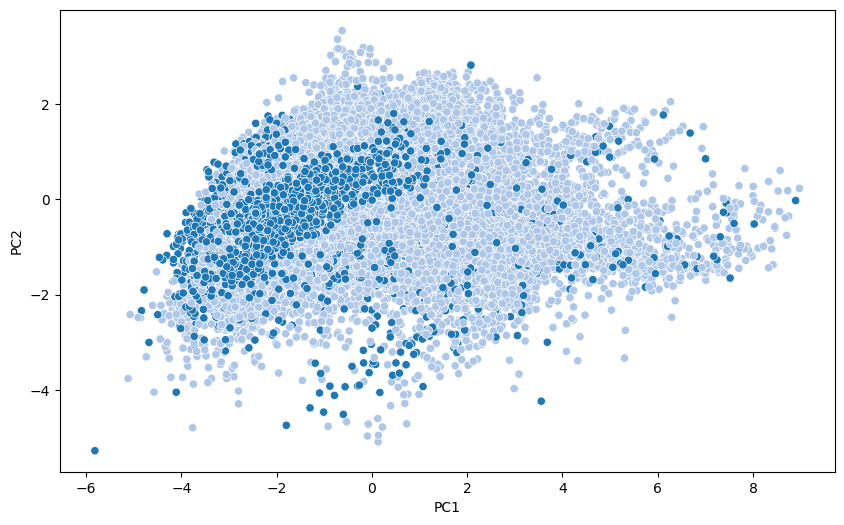

In [4]:
# visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='metro_label', 
    data=mobility, 
    palette='tab20',
    legend=False
)
plt.xlabel("PC1")
plt.ylabel("PC2")

Text(0, 0.5, 'PC2')

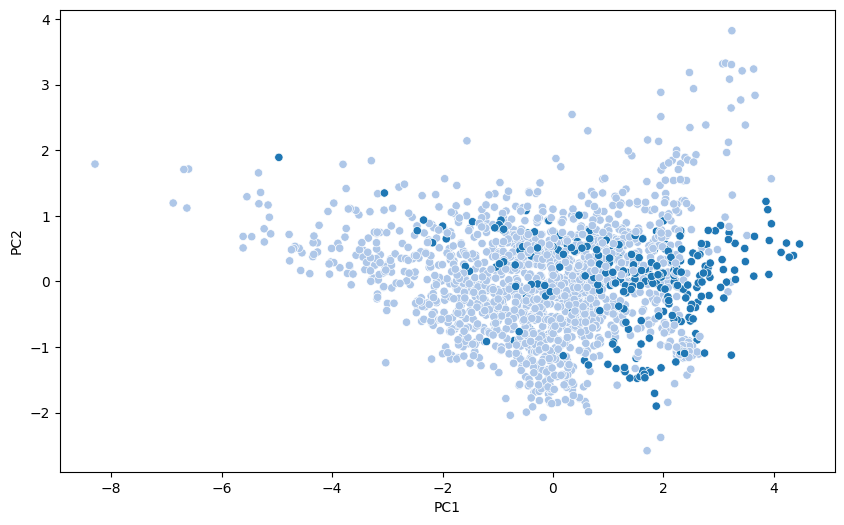

In [5]:
# visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='metro_label', 
    data=monthly, 
    palette='tab20',
    legend=False
)
plt.xlabel("PC1")
plt.ylabel("PC2")

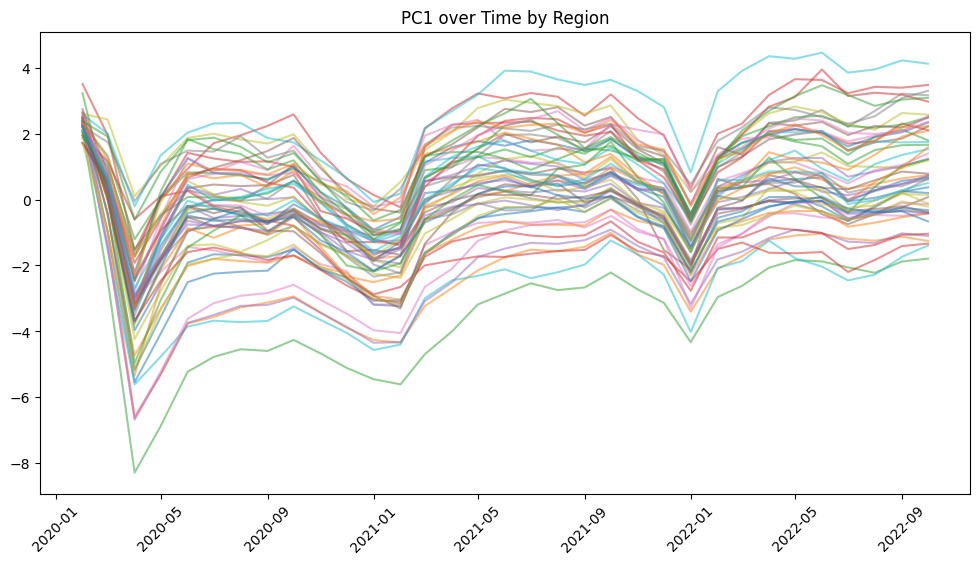

In [6]:
monthly['year_month_dt'] = monthly['year_month'].dt.to_timestamp()

plt.figure(figsize=(12,6))
for region, group in monthly.groupby('sub_region_2'):
    plt.plot(group['year_month_dt'], group['PC1'], alpha=0.5)
plt.xticks(rotation=45)
plt.title('PC1 over Time by Region')
plt.show()

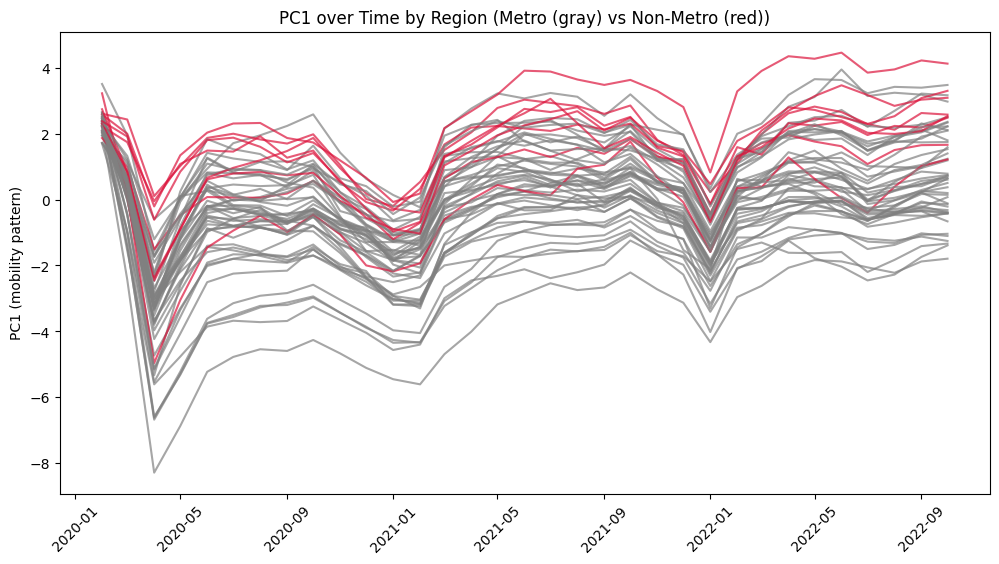

In [10]:
plt.figure(figsize=(12,6))

# Plot each region, coloring by metro status
for (region, metro_label), group in monthly.groupby(['sub_region_2','metro_label']):
    if metro_label == 1:  # Metro
        plt.plot(group['year_month_dt'], group['PC1'], color='gray', alpha=0.7)
    else:  # Non-metro
        plt.plot(group['year_month_dt'], group['PC1'], color='crimson', alpha=0.7)

plt.xticks(rotation=45)
plt.ylabel('PC1 (mobility pattern)')
plt.title('PC1 over Time by Region (Metro (gray) vs Non-Metro (red))')
plt.show()

In [ ]:
loadings = pd.DataFrame(pca_m.components_.T, 
                        index=mobility_feats,  # your original categories
                        columns=[f'PC{i+1}' for i in range(len(pca.components_))])


print(loadings['PC1'])

retail_and_recreation_percent_change_from_baseline    0.427993
grocery_and_pharmacy_percent_change_from_baseline     0.440444
transit_stations_percent_change_from_baseline         0.387987
workplaces_percent_change_from_baseline               0.488612
residential_percent_change_from_baseline             -0.483276
Name: PC1, dtype: float64


/var/folders/lv/9m_qv53944x04_1mpk21jgtc0000gn/T/ipykernel_1559/105621702.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


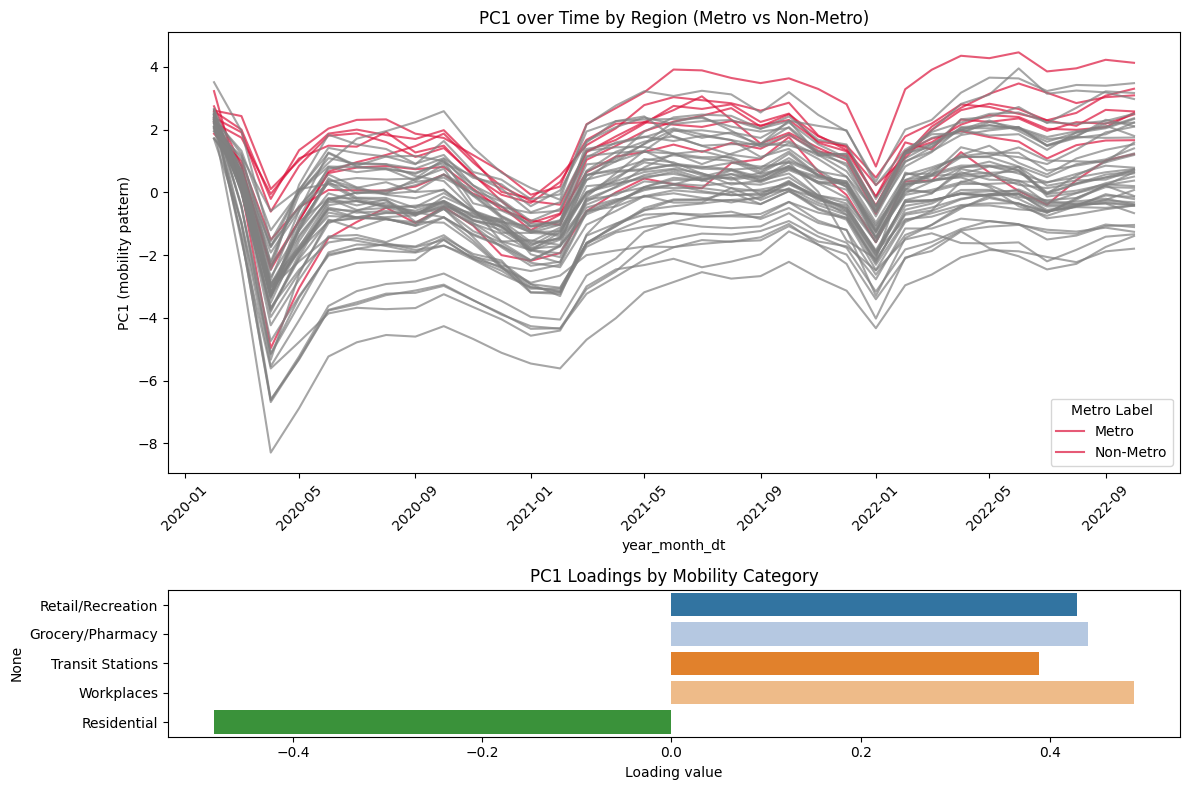

In [20]:

short_names = {
    'retail_and_recreation_percent_change_from_baseline': 'Retail/Recreation',
    'grocery_and_pharmacy_percent_change_from_baseline': 'Grocery/Pharmacy',
    'transit_stations_percent_change_from_baseline': 'Transit Stations',
    'workplaces_percent_change_from_baseline': 'Workplaces',
    'residential_percent_change_from_baseline': 'Residential'
}
loadings_short = loadings.rename(index=short_names)

monthly['year_month_dt'] = monthly['year_month'].dt.to_timestamp()

# fig with 2 subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

# top: pc1 over time
ax = axes[0]
sns.lineplot(
    data=monthly,
    x='year_month_dt',
    y='PC1',
    hue='metro_label',  # 1=Metro, 0=Rural
    units='sub_region_2',
    estimator=None,
    palette={0: 'crimson', 1: 'gray'},
    alpha=0.7,
    ax=ax,
    legend='full'
)

ax.set_ylabel('PC1 (mobility pattern)')
ax.set_title('PC1 over Time by Region (Metro vs Non-Metro)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Metro Label', labels=['Metro', 'Non-Metro'])

# --- Bottom subplot: PC1 loadings ---
ax2 = axes[1]
sns.barplot(
    x=loadings_short['PC1'].values,
    y=loadings_short['PC1'].index,
    palette='tab20',
    ax=ax2
)
ax2.set_xlabel('Loading value')
ax2.set_title('PC1 Loadings by Mobility Category')

plt.tight_layout()
plt.show()

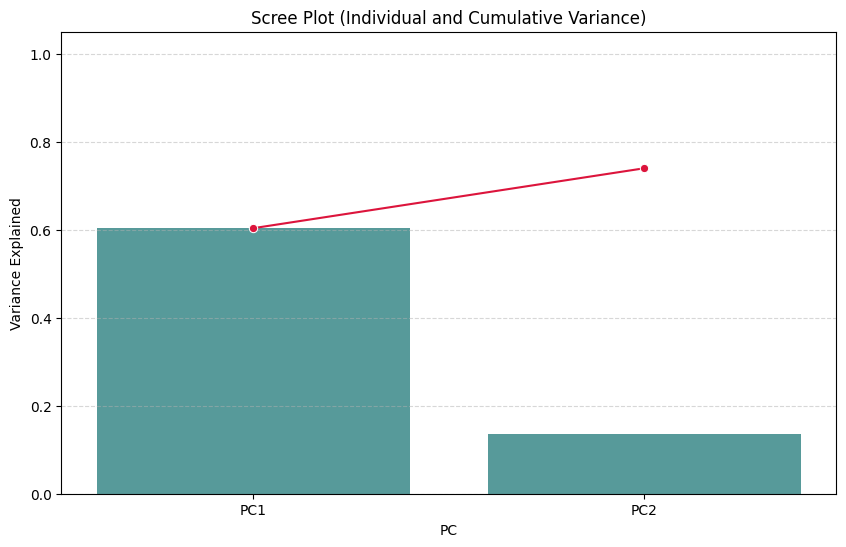

In [25]:
# prep variance explained
expl_var = pca_m.explained_variance_ratio_
cum_var = np.cumsum(expl_var)

# Make a DataFrame for plotting
scree_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(expl_var))],
    'Variance': expl_var,
    'Cumulative': cum_var
})

plt.figure(figsize=(10,6))

# Barplot for individual variance
sns.barplot(x='PC', y='Variance', data=scree_df, color='teal', alpha=0.7)

# Lineplot for cumulative variance
sns.lineplot(x='PC', y='Cumulative', data=scree_df, marker='o', color='crimson')

plt.ylabel('Variance Explained')
plt.title('Scree Plot (Individual and Cumulative Variance)')
plt.ylim(0,1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()